## API exploration

Exploring the API of "https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/stations" to assess feasibility of a ML project.

In [2]:
# %load_ext autoreload
# %autoreload 2

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd

from hydrosense.database.ades import GestionnairePiezometrie
from hydrosense.database.entite import Entite

## Data Engineering

**To do list**

- Creer un dataframe à partir du JSON. Refactoriser le code de la fonction en module. DONE
- Explorer les données vendéennes. 
examples : CHallans BSS001LADS   Entité  121
        niort
        la roche s yon BSS001MHUZ  Entité
        Cholet   BSS001JWAE          Entité       181
          ruffec BSS001RRGC

- Essayer de charger la vendée en entier: DONE
- Trouver le nombre total de stations: DONE
- Moyenne des piezos de vendée.                   
- Sortir les coordonnées géographiques. Lambert 93

In [2]:
gestionnaire = GestionnairePiezometrie(dossier_sortie="../raw_data")

In [ ]:
extracteur = Entite()
extracteur.total_stations(date_recherche = '2026-01-01', nb_mesures_piezo_min = 2000)

Nombre total de stations trouvées : 2745


In [ ]:
liste_stations = extracteur.rechercher_stations(date_recherche = '2026-01-01', nb_mesures_piezo_min = 2000)

Recherche des stations avec les paramètres : {'format': 'json', 'size': 5000, 'nb_mesures_piezo_min': 700, 'date_recherche': '2026-01-01'}...
-> 2745 stations trouvées !


In [ ]:
def piezo_stats(bss_id):
    output = {}
    try:
        df = gestionnaire.telecharger_forage(bss_id)
    except:
        return None
    n_mesures = df.shape[0]

    y = df['niveau_nappe_eau']
    t = pd.to_datetime(df['date_mesure'])

    # t.iloc[0], t.iloc[-1], (t.iloc[-1]-t.iloc[0]).days, len(t)

    output['mean'] = y.mean()
    output['max'] = y.max()
    output['min'] = y.min()
    output['median'] = y.median()
    output['std'] = y.std()
    output['missing'] = y.isna().sum() + int((t.iloc[-1]-t.iloc[0]).days) - n_mesures


    return output

In [10]:
%%time
i = 0
for s in liste_stations[1000:1500]:
    gestionnaire.telecharger_forage(s)
    i += 1

Info: données BSS001TXRW déja présente
Info: données BSS002KQBB déja présente
Info: données BSS002CTVK déja présente
Info: données BSS002GXEY déja présente
Info: données BSS001STQY déja présente
Info: données BSS002PGEW déja présente
Téléchargement de BSS002FEUF...
  -> Succès : 15474 mesures sauvegardées dans piezo_BSS002FEUF.csv
Info: données BSS001LFKP déja présente
Info: données BSS002JBSG déja présente
Info: données BSS000HYEN déja présente
Info: données BSS001ESVX déja présente
Info: données BSS000PWRL déja présente
Info: données BSS002EAWW déja présente
Info: données BSS002JABQ déja présente
Info: données BSS001FDCV déja présente
Info: données BSS002NMUW déja présente
Info: données BSS001KYQK déja présente
Info: données BSS001KYUA déja présente
Info: données BSS000UASG déja présente
Info: données BSS000HGZW déja présente
Info: données BSS001WWEM déja présente
Info: données BSS000RQVQ déja présente
Info: données BSS000JBYK déja présente
Info: données BSS001KTSM déja présente
Info

In [ ]:
# df = gestionnaire.telecharger_forage('BSS000EMSB')
# y = df['niveau_nappe_eau']
# t = pd.to_datetime(df['date_mesure'])
# t.iloc[0], t.iloc[-1], (t.iloc[-1]-t.iloc[0]).days, len(t)

# t.diff().unique()

# import matplotlib.pyplot as plt
# plt.plot(df['date_mesure'], df['niveau_nappe_eau'], 'x')


Téléchargement de BSS000EMSB...
  -> Succès : 9989 mesures sauvegardées dans piezo_BSS000EMSB.csv


(Timestamp('1972-02-11 00:00:00'),
 Timestamp('2026-05-29 00:00:00'),
 19831,
 9989)

## Check that all the datasets are in thCheck all the files are present in the datasets.

### Emplacement géographiques des différentes stations de mesure.

La liste des stations existentes est stockée différemment des données piezometriques individuelles. Il y une autre database JSON.

On peut rechercher la base par département ou par entité BDlisa.

Mais nous sommes limité à 20000 lignes par requête.

In [ ]:


# Entite().rechercher_stations(taille_max= 20000)
print(Entite().total_stations(date_recherche = '2026-01-01', nb_mesures_piezo_min = 1000))


Nombre total de stations trouvées : 2689
None
CPU times: user 22.6 ms, sys: 3.81 ms, total: 26.4 ms
Wall time: 165 ms


In [75]:
vendee = Entite()
print("--- Recherche par département ---")
print(s85 := vendee.rechercher_stations(code_dep = "85", date_recherche="2025-05-05"))

--- Recherche par département ---
Recherche des stations avec les paramètres : {'format': 'json', 'size': 5000, 'nb_mesures_piezo_min': 1, 'date_recherche': '2025-05-05', 'code_departement': '85'}...
-> 44 stations trouvées !
['BSS001JNKL', 'BSS001MELY', 'BSS001PGFU', 'BSS001NNMN', 'BSS001NLTS', 'BSS001MDPN', 'BSS001NMRJ', 'BSS001MKDU', 'BSS001LADS', 'BSS001KYWM', 'BSS001PEED', 'BSS001KYQK', 'BSS001KYUA', 'BSS001PEPF', 'BSS001KYXH', 'BSS001PFCH', 'BSS001PFFH', 'BSS001KYXF', 'BSS001PEFC', 'BSS001PEXS', 'BSS001PFNL', 'BSS001KYWZ', 'BSS001NMFQ', 'BSS001PFLX', 'BSS001KYXA', 'BSS001NKUA', 'BSS001JNKN', 'BSS001MKMT', 'BSS001MHUZ', 'BSS001MFCH', 'BSS001JPGZ', 'BSS001LDCR', 'BSS001NMFS', 'BSS001NHNA', 'BSS001NMZR', 'BSS001JPGP', 'BSS001NLJH', 'BSS001NMSL', 'BSS001NMQC', 'BSS004AXJB', 'BSS004AXHK', 'BSS001PGPK', 'BSS001NKUB', 'BSS001NKBJ']


In [ ]:
catalogue = vendee.generer_df(raw= False)

print("Taille du dataframe : ", catalogue.shape)
print(catalogue.columns)
display(catalogue.head())

# # A VOIR POUR PANDAS
# print(catalogue['geometry'].head())
# print(catalogue['geometry'][1])

-> Catalogue structuré en DataFrame (44 lignes, 22 colonnes).
Taille du dataframe :  (44, 22)
Index(['code_bss', 'urn_bss', 'date_debut_mesure', 'date_fin_mesure',
       'code_commune_insee', 'nom_commune', 'x', 'y', 'codes_bdlisa',
       'urns_bdlisa', 'geometry', 'bss_id', 'altitude_station',
       'nb_mesures_piezo', 'code_departement', 'nom_departement', 'libelle_pe',
       'profondeur_investigation', 'codes_masse_eau_edl', 'noms_masse_eau_edl',
       'urns_masse_eau_edl', 'date_maj'],
      dtype='object')


/home/charourou/projects/Projet_Hydrosense/hydrosense/entite.py:114: FutureWarning: Parsing 'CEST' as tzlocal (dependent on system timezone) is deprecated and will raise in a future version. Pass the 'tz' keyword or call tz_localize after construction instead
/home/charourou/projects/Projet_Hydrosense/hydrosense/entite.py:114: FutureWarning: Parsing 'CET' as tzlocal (dependent on system timezone) is deprecated and will raise in a future version. Pass the 'tz' keyword or call tz_localize after construction instead


,code_bss,urn_bss,date_debut_mesure,date_fin_mesure,code_commune_insee,nom_commune,x,y,codes_bdlisa,urns_bdlisa,...,altitude_station,nb_mesures_piezo,code_departement,nom_departement,libelle_pe,profondeur_investigation,codes_masse_eau_edl,noms_masse_eau_edl,urns_masse_eau_edl,date_maj
0,05068X0028/SP010,http://services.ades.eaufrance.fr/pointeau/050...,1990-12-11 00:00:00+00:00,2026-05-18 00:00:00+00:00,85083,L'Épine,-2.240129,46.990356,121AF01,http://reseau.eaufrance.fr/geotraitements/bdli...,...,2.25,12827,85,Vendée,L'Epine forage du terrain-neuf (L'Epine-85),16.5,GG036,Ile de Noirmoutier,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,NaT
1,05604X0162/SF1,http://services.ades.eaufrance.fr/pointeau/056...,2011-01-01 00:00:00+00:00,2026-05-18 00:00:00+00:00,85189,Notre-Dame-de-Riez,-1.884899,46.768020,121AF01,http://reseau.eaufrance.fr/geotraitements/bdli...,...,7.0,5397,85,Vendée,Forage du Breuil( Notre Dame de Riez - 85),24.0,GG033,Sables et calcaires du bassin tertiaire de Jau...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,NaT
2,06101X0202/SP1,http://services.ades.eaufrance.fr/pointeau/061...,1987-07-10 00:00:00+00:00,2026-05-18 00:00:00+00:00,85168,Oulmes,-0.687081,46.408744,"360AA07,362AF01",http://reseau.eaufrance.fr/geotraitements/bdli...,...,10.2,12201,85,Vendée,"forage du Gd Nati (Oulmes,85)",41.0,GG042,Calcaires et marnes du Lias et Dogger du Sud-V...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,NaT
3,05867X0152/SR1,http://services.ades.eaufrance.fr/pointeau/058...,1987-08-31 00:00:00+00:00,2026-02-24 00:00:00+00:00,85092,Fontenay-le-Comte,-0.836079,46.452581,None,,...,4.71,11883,85,Vendée,"forage du Gros Noyer (Fontenay le Comte,85)",25.0,GG042,Calcaires et marnes du Lias et Dogger du Sud-V...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,NaT
4,05861X0113/SF2,http://services.ades.eaufrance.fr/pointeau/058...,1987-09-20 00:00:00+00:00,2026-05-18 00:00:00+00:00,85290,Thiré,-1.013552,46.541679,None,,...,51.93,11784,85,Vendée,"forage de la la Ville Morte(Thiré,85)",53.0,GG042,Calcaires et marnes du Lias et Dogger du Sud-V...,[http://www.sandre.eaufrance.fr/geo/MasseDEauS...,NaT


#### Scatter Plot geographique

Le module geopandas est un peu obscur pour le moment. 

On fait simple pour le moment. Matplotlib + contextily

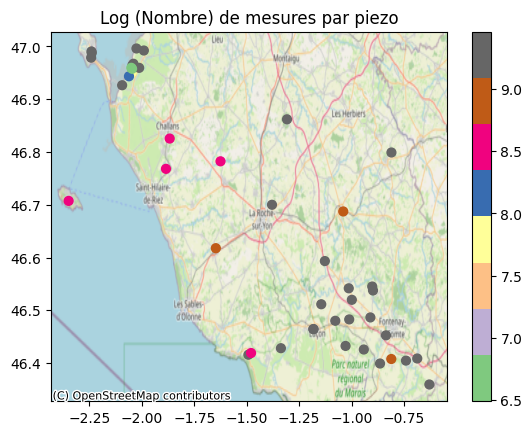

In [79]:
import matplotlib.pyplot as plt
import contextily as cx

sc = np.log(catalogue['nb_mesures_piezo'])
plt.scatter(catalogue['x'], catalogue['y'], marker= 'o',
            s= 40 ,
            c = sc,
            cmap = 'Accent')

# On précise crs="EPSG:4326" car vos données sont en long/lat (WGS84)
cx.add_basemap(plt.gca(), crs="EPSG:4326", source=cx.providers.OpenStreetMap.Mapnik)
plt.title('Log (Nombre) de mesures par piezo')
h = plt.colorbar()
plt.show()


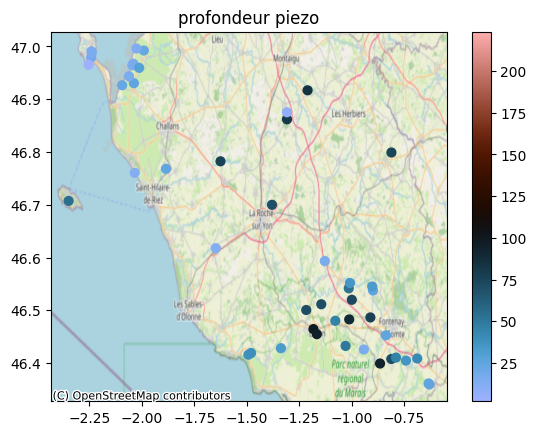

In [ ]:
plt.scatter(catalogue['x'], catalogue['y'], marker= 'o',
            s= 40 ,
            c = catalogue['profondeur_investigation'],
            cmap = 'berlin')

cx.add_basemap(plt.gca(), crs="EPSG:4326", source=cx.providers.OpenStreetMap.Mapnik)
plt.title('Profondeur Investigation')
plt.colorbar()
plt.show()

### Recherche par entité

Est-ce qu'un piezo peut avoir plusieurs entités rattachées.

5000+ stations pour entité "113AC10", cela paraît excessif

In [ ]:
print("\n--- Recherche par entité hydrogéologique ---")
stations_meme_nappe = Entite().rechercher_stations(code_bdlisa="121AF01")
print(f"\nVoici les 5 premières stations de la nappe : {stations_meme_nappe[:5]}")


--- Recherche par entité hydrogéologique ---
Recherche des stations avec les paramètres : {'format': 'json', 'size': 5000, 'code_bdlisa': '121AF01'}...
-> 3 stations trouvées !

Voici les 5 premières stations de la nappe : ['BSS001JNKL', 'BSS001MELY', 'BSS001LADS']
Nombre total de stations trouvées : 23308


### Recherche par département

Comment chercher les piezos qui ne sont plus d'actualités ?N

In [ ]:
print("\n--- Recherche par département 44 ---")
s44 = Entite().rechercher_stations(code_dep="44")

collecteur = GestionnairePiezometrie(dossier_sortie= '/home/charourou/projects/hydrosense/data/')



--- Recherche par département 44 ---
Recherche des stations avec les paramètres : {'format': 'json', 'size': 5000, 'code_departement': '44'}...
-> 58 stations trouvées !


In [ ]:
derniere_collecte = []

for nom_piezo in s44[:]:
    df = collecteur.telecharger_forage(nom_piezo)
    if not type(df) == bool:
        derniere_collecte.append(df['date_mesure'].iloc[-1])
    else:
        s44.remove(nom_piezo)

Info: données BSS001EUMW déja présente
Info: données BSS001GPCB déja présente
Info: données BSS001EUZL déja présente
Info: données BSS001JPMN déja présente
Info: données BSS001EUJD déja présente
Info: données BSS001ETCD déja présente
Info: données BSS001DJDQ déja présente
Téléchargement de BSS001DJDC...
  -> Erreur lors du traitement de BSS001DJDC : No columns to parse from file
Info: données BSS001ETCE déja présente
Info: données BSS001DKCX déja présente
Info: données BSS001JRHS déja présente
Info: données BSS001HBQB déja présente
Info: données BSS001EUZK déja présente
Info: données BSS001JPMP déja présente
Info: données BSS001HBQA déja présente
Info: données BSS001DMWC déja présente
Info: données BSS001JPMQ déja présente
Info: données BSS001EUHC déja présente
Info: données BSS001DJDP déja présente
Info: données BSS001EUKK déja présente
Info: données BSS001ESVX déja présente
Info: données BSS001ESVY déja présente
Info: données BSS001EUZH déja présente
Info: données BSS001DKCW déja pré

In [12]:
derniere_collecte

['2026-05-28',
 '2026-05-28',
 '2010-05-28',
 '2024-03-22',
 '2015-12-14',
 '2026-05-27',
 '2005-06-18',
 '2026-05-28',
 '1998-03-16',
 '2026-05-27',
 '2026-05-28',
 '2026-05-27',
 '2026-05-27',
 '2026-05-28',
 '2026-04-30',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2020-06-25',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-04-30',
 '2026-05-27',
 '2026-04-30',
 '2026-05-27',
 '2026-05-27',
 '2005-10-18',
 '2026-05-27',
 '2025-12-01',
 '2008-03-06',
 '2026-05-28',
 '2026-05-27',
 '2019-02-11',
 '2026-04-06',
 '2026-05-26',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-26',
 '2026-05-27',
 '2026-05-22',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-27',
 '2026-05-28',
 '2026-05-28',
 '2026-05-27',
 '2026-05-27',
 '2026-05-26']

### Plots et un peu d'exploration de données. 


- plot dans le temps

- comparaison des données entre deux piezometres

- valeurs moyennes sur plusieurs entitées

- geopandas pour une representation graphique